DATA UNDERSTANDING

1. LOAD DATA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("online_retail.csv")

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


2. CHECK MISSING VALUE & DUPLICATE

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
total = df.duplicated().sum()
print(f"Total Duplicate value = ", total)

Total Duplicate value =  5268


3.CHECK NEGATIVE VALUE

In [7]:
p =(df["Quantity"] < 0).sum()
print(f"Total Negative value in column Quantity : ", p)

Total Negative value in column Quantity :  10624


4. CHECK OUTLAYER

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Number of Outliers: {len(outliers)}")


Column: Quantity
Number of Outliers: 58619

Column: UnitPrice
Number of Outliers: 39627

Column: CustomerID
Number of Outliers: 0


DATA WRANGLING


In [9]:
df_clean = df.copy()

1. CHANGE DATA TYPE

In [10]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


2. DROP DUPLICATED VALUES

In [11]:
df_clean = df_clean.drop_duplicates()

2. FEATURE ENGINEERING FOR MISSING VALUES AND ANOMALIES VALUES

In [12]:
df_clean["Is_Return"] = (df_clean["Quantity"] <= 0).astype(int)
df_clean["Has_CustomerID"] = df_clean["CustomerID"].notna().astype(int)
df_clean["InvoiceHour"] = df_clean["InvoiceDate"].dt.hour

3. NEW COLOUMN TOTAL PRICE

In [13]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

FEATURE SELECTION

In [14]:
features = [
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "Is_Return",
    "Has_CustomerID",
    "InvoiceHour",
]

EXPLORATORY DATA ANALYSIS

In [24]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Is_Return,541909.0,0.019605,0.0,0.0,0.0,0.0,1.0,0.138638
Has_CustomerID,541909.0,0.750733,0.0,1.0,1.0,1.0,1.0,0.432589
InvoiceHour,541909.0,13.078729,6.0,11.0,13.0,15.0,20.0,2.44327
TotalPrice,541909.0,17.987795,-168469.6,3.4,9.75,17.4,168469.6,378.810824


1. Numerical Variable Distribution

In [ ]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'Distribution: {col}')
    axes[i][0].set_xlabel(col)

    sns.boxplot(x=df_clean[col], ax=axes[i][1], color='lightcoral')
    axes[i][1].set_title(f'Boxplot: {col}')
    axes[i][1].set_xlabel(col)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001E236B64B80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

2. TOP SELLING PRODUCT & TOP REVENUE PRODUCT

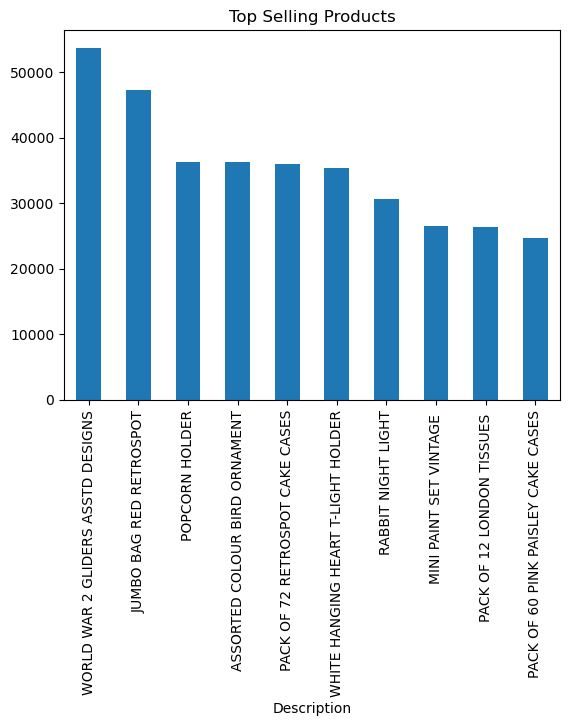

In [15]:
top_products = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")
plt.title("Top Selling Products")
plt.show()

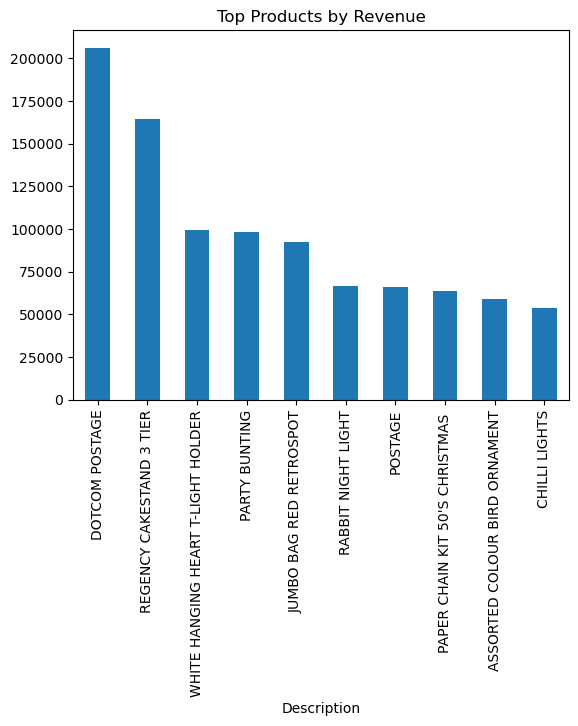

In [16]:
top_revenue = df_clean.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

top_revenue.plot(kind="bar")
plt.title("Top Products by Revenue")
plt.show()

3. SALES BY COUNTRY

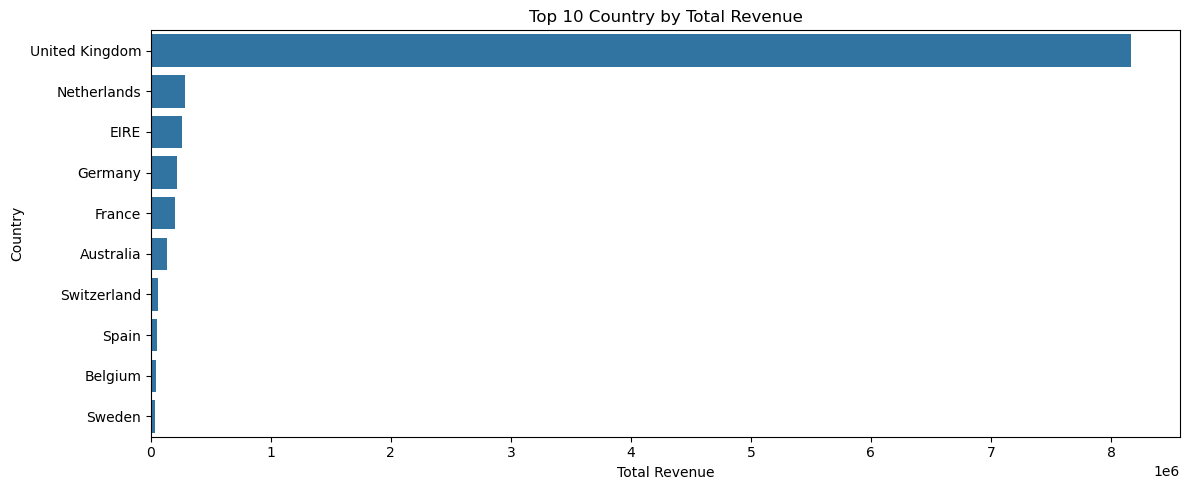

In [17]:
country_sales = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title('Top 10 Country by Total Revenue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

4. SALES TREND & TIME ANALYSIS

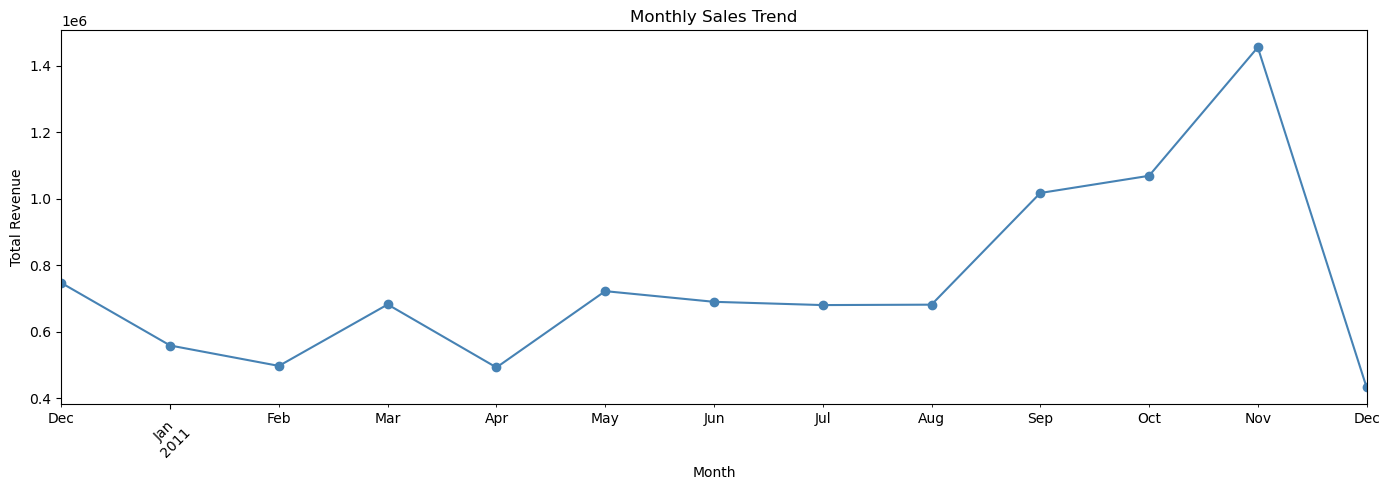

In [18]:
monthly_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

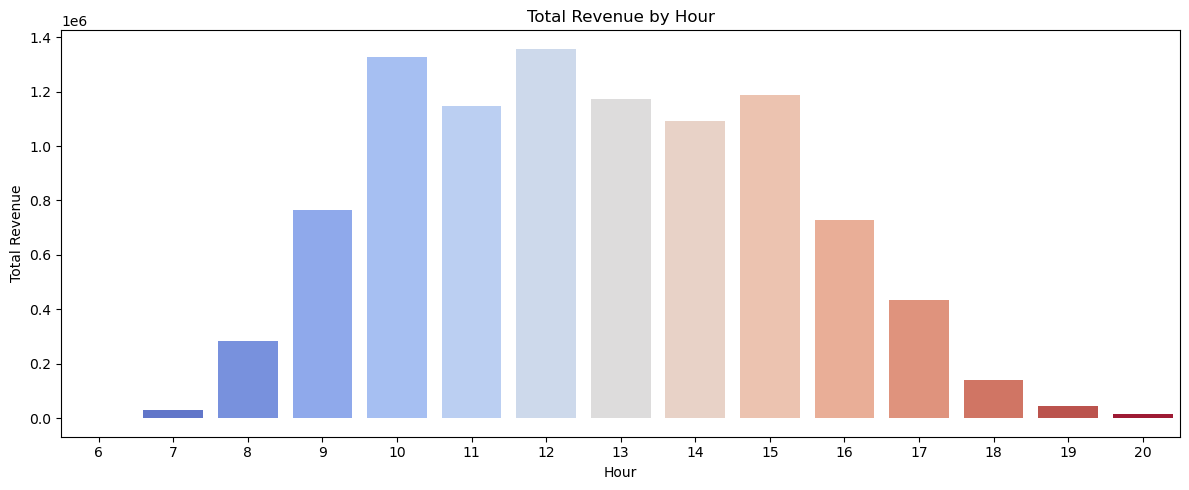

In [19]:
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hour_sales = df_clean.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=hour_sales.index, y=hour_sales.values, hue=hour_sales.index, palette='coolwarm', legend=False)
plt.title('Total Revenue by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

5.CUSTOMER SPENDING

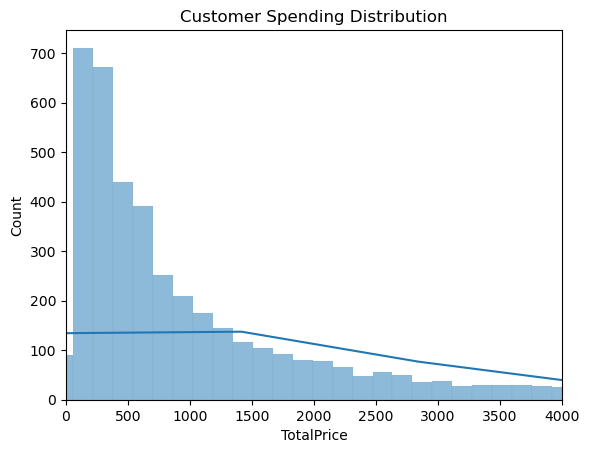

In [20]:
customer_spending = df_clean.groupby("CustomerID")["TotalPrice"].sum()

sns.histplot(customer_spending, kde=True)
plt.xlim(left =0 )
plt.xlim(right = 4000)
plt.title("Customer Spending Distribution")
plt.show()

6. CORRELATION

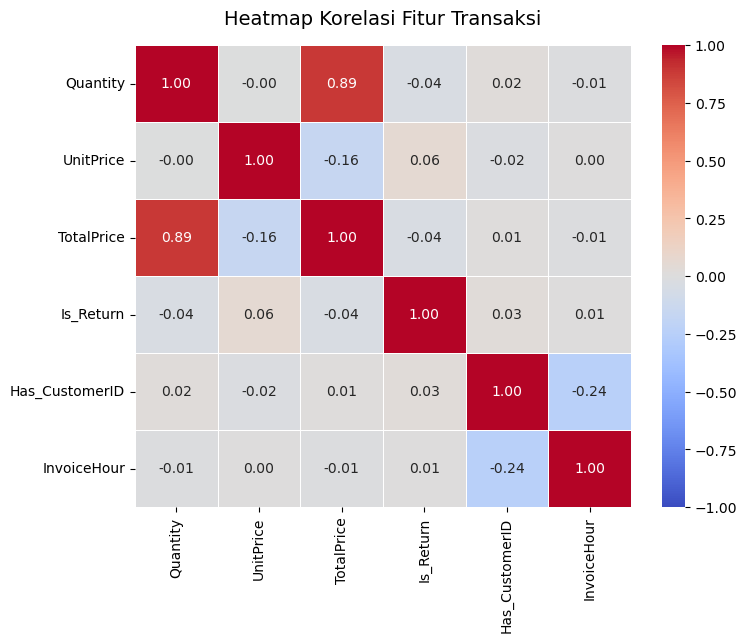

In [21]:
# 1. Hitung matriks korelasi
corr_matrix = df_clean[features].corr()

# 2. Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  # Menampilkan nilai angka korelasi di setiap kotak
    fmt=".2f",  # Format 2 angka di belakang koma
    cmap="coolwarm",  # Skema warna (Merah = Positif, Biru = Negatif)
    vmin=-1,
    vmax=1,  # Membatasi skala dari -1 sampai 1
    linewidths=0.5,  # Jarak antar kotak
)

plt.title("Heatmap Korelasi Fitur Transaksi", fontsize=14, pad=15)
plt.show()

BUSINESS INSIGHT ANALYSIS

1. TOP CUSTOMER ANALYSIS

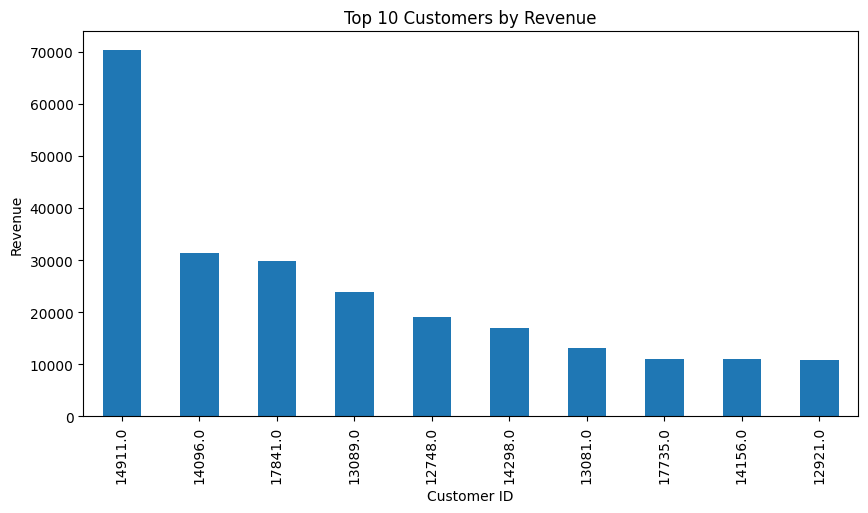

In [ ]:
top_customer = (
    df_clean.groupby('CustomerID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customer.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()

2. RFM ANALYSIS

In [ ]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,2783.37
12348.0,249,3,90.20
12349.0,19,1,939.75
12350.0,310,1,294.40
12352.0,36,7,1130.94


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4146.000000,4146.000000,4146.000000
mean,93.181380,3.918234,845.536065
std,100.015984,6.813902,1761.718973
min,1.000000,1.000000,1.700000
25%,18.000000,1.000000,171.970000
50%,51.000000,2.000000,402.440000
75%,145.000000,4.000000,957.142500
max,374.000000,193.000000,70372.020000


3. CUSTOMER DISTRIBUTION

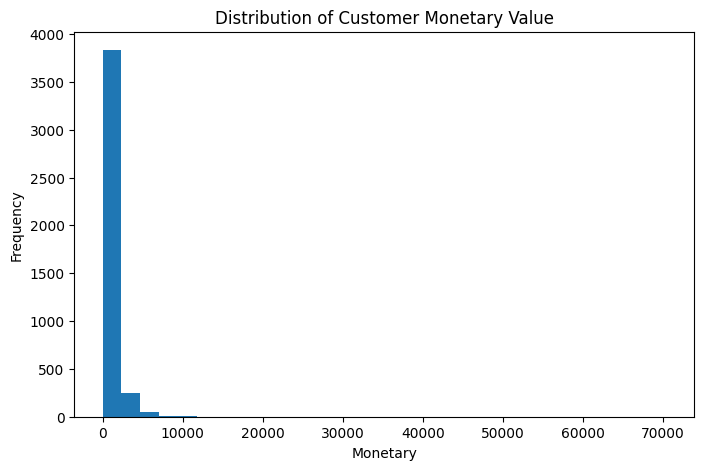

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    rfm['Monetary'],
    bins=30
)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Monetary')
plt.ylabel('Frequency')

plt.show()

4. RFM CORRELATION

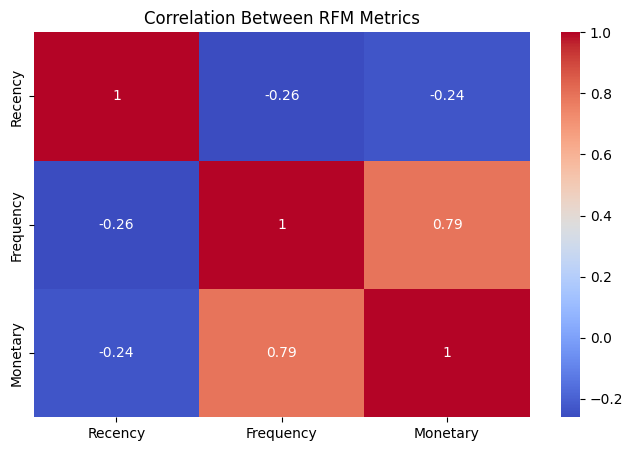

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between RFM Metrics')

plt.show()

5. REVENUE BY DAY OF WEEK

In [ ]:
df_clean['DayName'] = (
    df_clean['InvoiceDate']
    .dt.day_name()
)

weekday_sales = (
    df_clean.groupby('DayName')['TotalPrice']
    .sum()
)

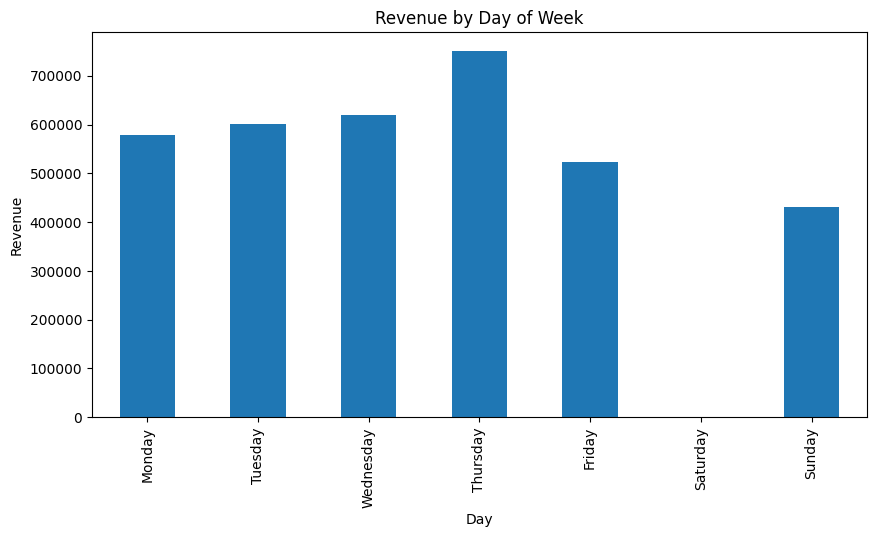

In [ ]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday']
weekday_sales = weekday_sales.reindex(order)

plt.figure(figsize=(10,5))

weekday_sales.plot(kind='bar')

plt.title('Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Revenue')

plt.show()

6. TOP 10 PRODUCT CONTRIBUTING REVENUE

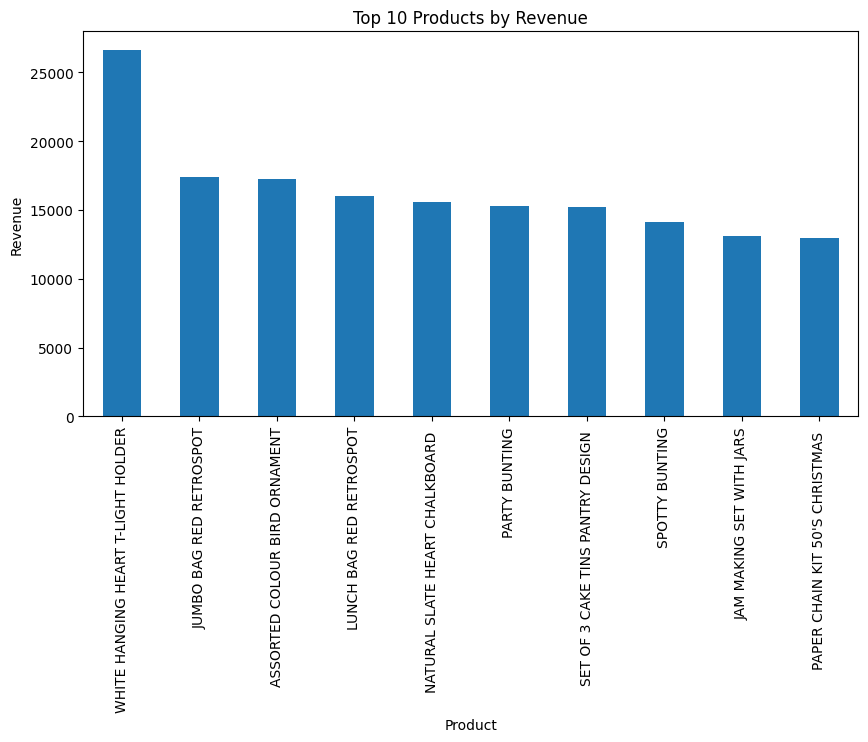

In [ ]:
top_revenue_products = (
    df_clean.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_revenue_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()